/jobfs/173289654.gadi-pbs/ipykernel_3147172/27791237.py:244: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved figure: /scratch/dt6/xw9650/tmp/regridded_AGCD/tas_AGCD_vs_BARRA2_trend_side_by_side.png


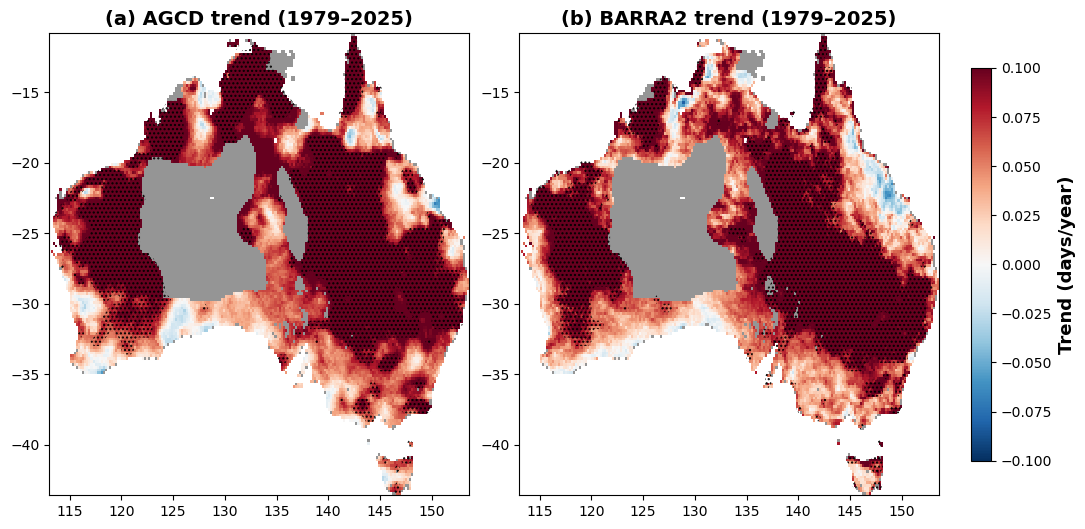

In [2]:
# ============================================================
# TAS TREND COMPARISON: AGCD vs BARRA2 (SIDE-BY-SIDE)
# ============================================================

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# PATHS
# ============================================================

trend_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_AGCD/trend_maps"
)

agcd_file = trend_dir / "tas_AGCD_trend_1979_2025.nc"

barra2_file = Path(
    "/scratch/dt6/xw9650/tmp/regridded_BARRA2/trend_maps/tas_BARRA2_trend_1979_2025.nc"
)

output_dir = Path(
    "/scratch/dt6/xw9650/tmp/regridded_AGCD"
)
output_dir.mkdir(exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

agcd_ds = xr.open_dataset(agcd_file)
barra2_ds = xr.open_dataset(barra2_file)

# ============================================================
# LAND MASK
# ============================================================

mask_file = (
    "/scratch/dt6/xw9650/tmp/regridded/"
    "sftlf_AUS-18_ACCESS-ESM1-5_historical_r6i1p1f1_"
    "NSW-Government_NARCliM2-0-WRF412R3_v1-r1_fx.nc"
)

land_mask = xr.open_dataset(mask_file)["sftlf"] > 50

# ============================================================
# REGION MASK
# ============================================================

mask_region = xr.open_dataarray(
    "/g/data/w97/mg5624/RF_project/masks/original_awra_awap_mask.nc"
)

def regrid_mask(mask, target):
    mask = mask.sortby("lat")
    mask = mask.astype(int)

    target = target.sel(
        lat=slice(mask.lat.min().values, mask.lat.max().values),
        lon=slice(mask.lon.min().values, mask.lon.max().values),
    )

    return mask.interp_like(target, method="nearest").astype(bool)

# ============================================================
# ALIGN DATASETS
# ============================================================

agcd_ds, land_mask = xr.align(agcd_ds, land_mask, join="inner")
barra2_ds, land_mask = xr.align(barra2_ds, land_mask, join="inner")

# ============================================================
# APPLY MASKS
# ============================================================

agcd_land = agcd_ds.where(land_mask)
barra2_land = barra2_ds.where(land_mask)

agcd_mask = regrid_mask(mask_region, agcd_land)
barra2_mask = regrid_mask(mask_region, barra2_land)

agcd_land = agcd_land.where(agcd_mask)
barra2_land = barra2_land.where(barra2_mask)

# ============================================================
# EXCLUDED AREAS
# ============================================================

excluded_agcd = land_mask & (~agcd_mask)
excluded_barra2 = land_mask & (~barra2_mask)

# ============================================================
# FIGURE LAYOUT (SIDE-BY-SIDE)
# ============================================================

fig = plt.figure(figsize=(14, 6))

gs = fig.add_gridspec(
    1, 2,
    wspace=0.12
)

ax_agcd = fig.add_subplot(gs[0, 0])
ax_barra2 = fig.add_subplot(gs[0, 1])

# ============================================================
# FIX MAP STRETCHING
# ============================================================

for ax in [ax_agcd, ax_barra2]:
    ax.set_aspect("auto")
# for ax in [ax_agcd, ax_barra2]:
#     ax.set_aspect("equal", adjustable="box")

# ============================================================
# COMMON SETTINGS
# ============================================================

vmin, vmax = -0.1, 0.1
gray_cmap = plt.cm.Greys

# ============================================================
# EXCLUDED MASK BACKGROUND
# ============================================================

xr.where(excluded_agcd, 1, np.nan).plot(
    ax=ax_agcd,
    cmap=gray_cmap,
    add_colorbar=False
)

xr.where(excluded_barra2, 1, np.nan).plot(
    ax=ax_barra2,
    cmap=gray_cmap,
    add_colorbar=False
)

# ============================================================
# TREND MAPS
# ============================================================

agcd_plot = agcd_land.trend.plot(
    ax=ax_agcd,
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)

barra2_plot = barra2_land.trend.plot(
    ax=ax_barra2,
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)

# ============================================================
# STIPPLING: AGCD (p <= 0.05)
# ============================================================

if "p_value" in agcd_land:
    sig = agcd_land["p_value"] <= 0.05
    step = 3

    ax_agcd.contourf(
        agcd_land.lon[::step],
        agcd_land.lat[::step],
        sig[::step, ::step].astype(int),
        levels=[0.5, 1],
        colors="none",
        hatches=["...."],
        alpha=0
    )

# ============================================================
# STIPPLING: BARRA2 (p <= 0.05)
# ============================================================

if "p_value" in barra2_land:
    sig = barra2_land["p_value"] <= 0.05
    step = 3

    ax_barra2.contourf(
        barra2_land.lon[::step],
        barra2_land.lat[::step],
        sig[::step, ::step].astype(int),
        levels=[0.5, 1],
        colors="none",
        hatches=["...."],
        alpha=0
    )

# ============================================================
# TITLES
# ============================================================

ax_agcd.set_title(
    "(a) AGCD trend (1979–2025)",
    fontsize=14,
    fontweight="bold"
)

ax_barra2.set_title(
    "(b) BARRA2 trend (1979–2025)",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# AXES CLEANUP
# ============================================================

for ax in [ax_agcd, ax_barra2]:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelsize=10)

# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(
    agcd_plot,
    ax=[ax_agcd, ax_barra2],
    shrink=0.85,
    pad=0.03
)

cbar.set_label(
    "Trend (days/year)",
    fontsize=13,
    fontweight="bold"
)

# ============================================================
# SAVE FIGURE
# ============================================================

fig_file = output_dir / "tas_AGCD_vs_BARRA2_trend_side_by_side.png"

plt.tight_layout()
fig.savefig(fig_file, dpi=300, bbox_inches="tight")

print(f"Saved figure: {fig_file}")

plt.show()